# Battery Current Time Series Prediction

## Import Library

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, SimpleRNN, GRU, Conv1D, MaxPool1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

2026-03-01 11:27:14.097501: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-01 11:27:14.144493: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-01 11:27:15.267253: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Load Dataset

In [2]:
df = pd.read_csv('~/AndroidMonitoring/Clustering/data/dataset/dataset.csv')
df.head()

,timestamp,cpu_usage,memory_usage,temperature,battery_level,battery_drain,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness
0,2026-02-28 12:50:59,62,67,34.6,78,-111.0,0,0.000000,0.00000,1,29
1,2026-02-28 12:51:03,32,70,34.6,78,-919.0,0,26.884218,192.38039,1,29
2,2026-02-28 12:51:07,48,69,34.6,78,-383.0,0,12.268097,520.40784,1,29
3,2026-02-28 12:51:11,35,68,34.6,78,-193.0,0,7.023991,524.93000,1,29
4,2026-02-28 12:51:15,46,69,34.6,78,-804.0,0,13.961425,396.78143,1,29


In [3]:
df.describe()

,cpu_usage,memory_usage,temperature,battery_level,battery_drain,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness
count,3423.000000,3423.000000,3423.000000,3423.000000,3423.000000,3423.0,3423.000000,3423.000000,3423.000000,3423.000000
mean,49.287759,74.572013,34.881770,47.049956,-332.404908,0.0,5.056843,81.529300,0.969325,25.799591
std,15.782952,3.649376,1.697165,17.314673,174.798104,0.0,10.513964,220.516434,0.172460,3.487664
min,24.000000,63.000000,30.800000,18.000000,-1369.000000,0.0,0.000000,0.000000,0.000000,22.000000
25%,36.000000,72.000000,34.100000,33.000000,-399.500000,0.0,0.421486,0.086403,1.000000,22.000000
50%,45.000000,74.000000,34.900000,47.000000,-284.000000,0.0,1.540133,2.265015,1.000000,29.000000
75%,57.000000,77.000000,35.600000,62.000000,-220.000000,0.0,5.199030,69.691555,1.000000,29.000000
max,100.000000,85.000000,39.200000,78.000000,-12.000000,0.0,183.420440,3450.904500,1.000000,29.000000


## Training

### Data Preparation

In [4]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

features_scaled = feature_scaler.fit_transform(
    df.drop(columns=['timestamp','temperature', 'battery_drain','battery_charging'])
)

target_scaled = target_scaler.fit_transform(
    df[['battery_drain']]
)

In [5]:
scaler_param = {
    "mean": feature_scaler.mean_.tolist(),
    "scale": feature_scaler.scale_.tolist(),
}

json_dir = os.path.expanduser(
    "~/AndroidMonitoring/TimeSeries/data/param/param.json")
os.makedirs(os.path.dirname(json_dir), exist_ok=True)

with open(json_dir, 'w') as outfile:
    json.dump(scaler_param, outfile)

In [6]:
features = features_scaled
target = target_scaled.flatten()
window_size = 150
horizon = 15
X = []
y = []

for i in range(len(features) - window_size - horizon):
    X.append(features[i:i+window_size])
    y.append(target[i+window_size:i+window_size+horizon])

X = np.array(X)
y = np.array(y)

print("Feature Shape: ", X.shape)
print("Label Shape: ", y.shape)

Feature Shape:  (3258, 150, 7)
Label Shape:  (3258, 15)


### Data Splitting

In [7]:
train = int(len(X) * 0.6)
val = int(len(X) * 0.8)

X_train, y_train = X[:train], y[:train]
X_val, y_val = X[train:val], y[train:val]
X_test, y_test = X[val:], y[val:]

print("Train Shape: ", X_train.shape)
print("Validation Shape: ", X_val.shape)
print("Test Shape: ", X_test.shape)

Train Shape:  (1954, 150, 7)
Validation Shape:  (652, 150, 7)
Test Shape:  (652, 150, 7)


### Model Architecture (Simple)

### RNN

In [8]:
model_rnn = Sequential([
    SimpleRNN(20,
        return_sequences=True,
        input_shape=(window_size, 7),
        activation='tanh'),
    SimpleRNN(10, activation='tanh'),
    Dense(15),
])
model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.summary()

E0000 00:00:1772339247.238355   24756 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772339247.246214   24756 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/abel-putra/AndroidMonitoring/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 150, 20)        │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,035 (4.04 KB)

 Trainable params: 1,035 (4.04 KB)

 Non-trainable params: 0 (0.00 B)

#### LSTM

In [9]:
model_lstm = Sequential([
    LSTM(10,
         return_sequences=True,
         input_shape=(window_size, 7),
         activation='relu'),
    LSTM(5, activation='relu'),
    Dense(15),
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 150, 10)        │           720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 5)              │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,130 (4.41 KB)

 Trainable params: 1,130 (4.41 KB)

 Non-trainable params: 0 (0.00 B)

#### GRU

In [10]:
model_gru = Sequential([
    GRU(15,
        return_sequences=True,
        input_shape=(window_size, 7),
        activation='relu'),
    GRU(10, activation='relu'),
    Dense(15)
])
model_gru.compile(optimizer='adam', loss='mse')
model_gru.summary()

/home/abel-putra/AndroidMonitoring/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 150, 15)        │         1,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 10)             │           810 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,055 (8.03 KB)

 Trainable params: 2,055 (8.03 KB)

 Non-trainable params: 0 (0.00 B)

### Model Architecture + CNN

In [11]:
model_cnn_rnn = Sequential([
    Conv1D(8,
           kernel_size=3,
           activation='relu',
           input_shape=(window_size, 7)),
    Conv1D(16,
           kernel_size=3,
           activation='relu'),
    Conv1D(8,
           kernel_size=3,
           activation='relu'),
    MaxPool1D(pool_size=2),

    SimpleRNN(20, activation='tanh'),
    Dense(15),
])

model_cnn_rnn.compile(optimizer='adam', loss='mse')
model_cnn_rnn.summary()

/home/abel-putra/AndroidMonitoring/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 148, 8)         │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 146, 16)        │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 144, 8)         │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 72, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 20)             │           580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           315 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,863 (7.28 KB)

 Trainable params: 1,863 (7.28 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model_cnn_lstm = Sequential([
    Conv1D(8,
           kernel_size=3,
           activation='relu',
           input_shape=(window_size, 7)),
    Conv1D(16,
           kernel_size=3,
           activation='relu'),
    Conv1D(8,
           kernel_size=3,
           activation='relu'),
    MaxPool1D(pool_size=2),

    LSTM(15, activation='tanh'),
    Dense(15),
])

model_cnn_lstm.compile(optimizer='adam', loss='mse')
model_cnn_lstm.summary()

/home/abel-putra/AndroidMonitoring/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 148, 8)         │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 146, 16)        │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 144, 8)         │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 72, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 15)             │         1,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │           240 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,648 (10.34 KB)

 Trainable params: 2,648 (10.34 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model_cnn_gru = Sequential([
    Conv1D(8,
           kernel_size=3,
           activation='relu',
           input_shape=(window_size, 7)),
    Conv1D(16,
           kernel_size=3,
           activation='relu'),
    Conv1D(8,
           kernel_size=3,
           activation='relu'),
    MaxPool1D(pool_size=2),

    GRU(20, activation='tanh'),
    Dense(15),
])

model_cnn_gru.compile(optimizer='adam', loss='mse')
model_cnn_gru.summary()

/home/abel-putra/AndroidMonitoring/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 148, 8)         │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 146, 16)        │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 144, 8)         │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 72, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 20)             │         1,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │           315 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,083 (12.04 KB)

 Trainable params: 3,083 (12.04 KB)

 Non-trainable params: 0 (0.00 B)

### Start Train

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
)

In [15]:
model_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 1.2298 - val_loss: 0.7989 - learning_rate: 0.0010
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.0725 - val_loss: 0.7856 - learning_rate: 0.0010
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.9874 - val_loss: 0.7481 - learning_rate: 0.0010
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.9349 - val_loss: 0.7147 - learning_rate: 0.0010
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.9098 - val_loss: 0.7363 - learning_rate: 0.0010
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.8995 - val_loss: 0.7614 - learning_rate: 0.0010
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.8889 - val_loss: 0.7171 - learning_rate: 0.0010
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.8816 - val_loss: 0.7227 - learning_rate: 5.0000e-04
Epoch 9/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.8767 - val_loss: 0.7334 - learning_rate: 5.0000e-04


In [16]:
model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 70045728.0000 - val_loss: 0.8049 - learning_rate: 0.0010
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 1.1667 - val_loss: 0.8050 - learning_rate: 0.0010
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 1.1654 - val_loss: 0.8065 - learning_rate: 0.0010
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 1.1644 - val_loss: 0.8072 - learning_rate: 5.0000e-04
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 1.1637 - val_loss: 0.8080 - learning_rate: 5.0000e-04


In [17]:
model_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 1.0759 - val_loss: 0.7157 - learning_rate: 0.0010
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 1.0127 - val_loss: 0.6940 - learning_rate: 0.0010
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.9236 - val_loss: 0.6678 - learning_rate: 0.0010
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.8894 - val_loss: 0.6727 - learning_rate: 0.0010
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.8789 - val_loss: 0.6735 - learning_rate: 0.0010
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.8722 - val_loss: 0.6705 - learning_rate: 0.0010
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.8674 - val_loss: 0.6729 - learning_rate: 5.0000e-04
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.8660 - val_loss: 0.6710 - learning_rate: 5.0000e-04


In [18]:
model_cnn_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.0699 - val_loss: 0.9054 - learning_rate: 0.0010
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.9617 - val_loss: 0.8339 - learning_rate: 0.0010
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.9167 - val_loss: 0.8539 - learning_rate: 0.0010
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.8915 - val_loss: 0.8392 - learning_rate: 5.0000e-04
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.8755 - val_loss: 0.9100 - learning_rate: 5.0000e-04


In [19]:
model_cnn_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 1.0512 - val_loss: 0.6835 - learning_rate: 0.0010
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.9410 - val_loss: 0.6820 - learning_rate: 0.0010
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.8957 - val_loss: 0.6713 - learning_rate: 0.0010
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.8798 - val_loss: 0.6866 - learning_rate: 5.0000e-04
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.8721 - val_loss: 0.6815 - learning_rate: 5.0000e-04


In [20]:
model_cnn_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 1.0602 - val_loss: 0.6950 - learning_rate: 0.0010
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.9334 - val_loss: 0.6798 - learning_rate: 0.0010
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.8910 - val_loss: 0.6938 - learning_rate: 0.0010
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.8810 - val_loss: 0.6814 - learning_rate: 5.0000e-04
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.8754 - val_loss: 0.6838 - learning_rate: 5.0000e-04


## Evaluation

In [21]:
pred_rnn = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)
pred_gru = model_gru.predict(X_test)
pred_cnn_rnn = model_cnn_rnn.predict(X_test)
pred_cnn_lstm = model_cnn_lstm.predict(X_test)
pred_cnn_gru = model_cnn_gru.predict(X_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [22]:
mae_rnn = mean_absolute_error(
    y_test.reshape(-1),
    pred_rnn.reshape(-1)
)
mae_lstm = mean_absolute_error(
    y_test.reshape(-1),
    pred_lstm.reshape(-1)
)
mae_gru = mean_absolute_error(
    y_test.reshape(-1),
    pred_gru.reshape(-1)
)
mae_cnn_rnn = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_rnn.reshape(-1)
)
mae_cnn_lstm = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_lstm.reshape(-1)
)
mae_cnn_gru = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_gru.reshape(-1)
)

print("MAE RNN:", mae_rnn)
print("MAE LSTM:", mae_lstm)
print("MAE GRU:", mae_gru)
print("MAE RNN (CNN):", mae_cnn_rnn)
print("MAE LSTM (CNN):", mae_cnn_rnn)
print("MAE GRU (CNN):", mae_cnn_rnn)

MAE RNN: 0.6632153027099238
MAE LSTM: 0.7164943018764497
MAE GRU: 0.6514234177146624
MAE RNN (CNN): 0.8034268169701777
MAE LSTM (CNN): 0.8034268169701777
MAE GRU (CNN): 0.8034268169701777


In [23]:
pred_rnn_real = target_scaler.inverse_transform(pred_rnn)
pred_lstm_real = target_scaler.inverse_transform(pred_lstm)
pred_gru_real = target_scaler.inverse_transform(pred_gru)
pred_cnn_rnn_real = target_scaler.inverse_transform(pred_cnn_rnn)
pred_cnn_lstm_real = target_scaler.inverse_transform(pred_cnn_lstm)
pred_cnn_gru_real = target_scaler.inverse_transform(pred_cnn_gru)
y_test_real = target_scaler.inverse_transform(y_test)

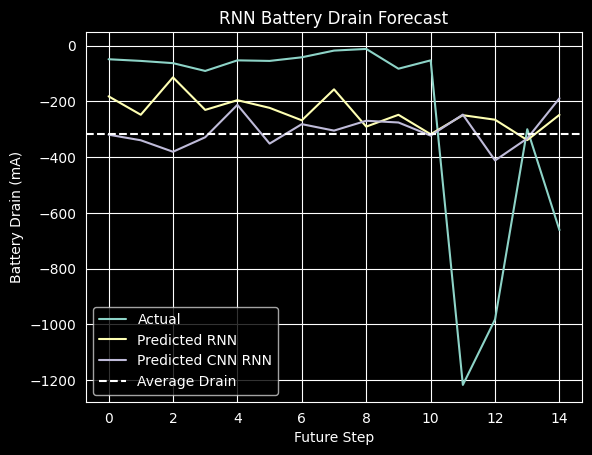

In [26]:
idx = np.random.randint(0, len(y_test_real))
avg_drain = np.mean(y_test_real)

plt.figure()
plt.plot(y_test_real[idx], label="Actual")
plt.plot(pred_rnn_real[idx], label="Predicted RNN")
plt.plot(pred_cnn_rnn_real[idx], label="Predicted CNN RNN")
plt.axhline(avg_drain, linestyle='--', label="Average Drain")
plt.title("RNN Battery Drain Forecast")
plt.xlabel("Future Step")
plt.ylabel("Battery Drain (mA)")
plt.legend()
plt.show()

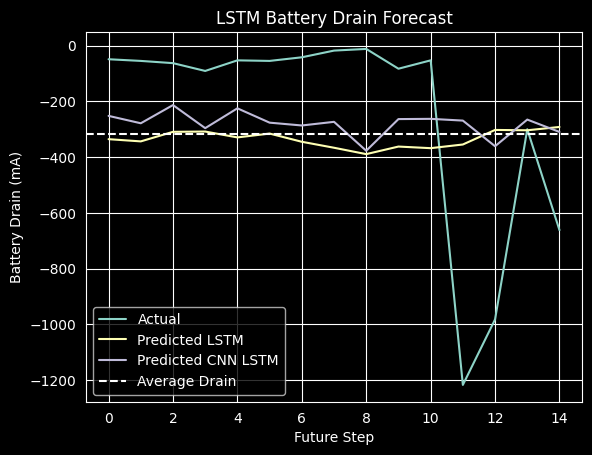

In [27]:
plt.figure()
plt.plot(y_test_real[idx], label="Actual")
plt.plot(pred_lstm_real[idx], label="Predicted LSTM")
plt.plot(pred_cnn_lstm_real[idx], label="Predicted CNN LSTM")
plt.axhline(avg_drain, linestyle='--', label="Average Drain")
plt.title("LSTM Battery Drain Forecast")
plt.xlabel("Future Step")
plt.ylabel("Battery Drain (mA)")
plt.legend()
plt.show()

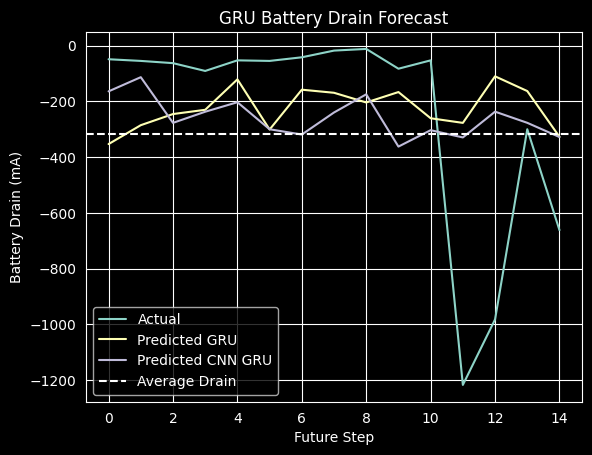

In [28]:
plt.figure()
plt.plot(y_test_real[idx], label="Actual")
plt.plot(pred_gru_real[idx], label="Predicted GRU")
plt.plot(pred_cnn_gru_real[idx], label="Predicted CNN GRU")
plt.axhline(avg_drain, linestyle='--', label="Average Drain")
plt.title("GRU Battery Drain Forecast")
plt.xlabel("Future Step")
plt.ylabel("Battery Drain (mA)")
plt.legend()
plt.show()